<a href="https://colab.research.google.com/github/tommihab/Haberstock-et-al.-2026-Supplementary-Material/blob/main/Haberstock_Ems_Model_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This is the fourth notebook of the study. Here the two ML models (LSTM vs RF) will be compared to eachother

In [ ]:
from pathlib import Path
import tensorflow as tf

# Define the GitHub repository
REPO_URL = "https://github.com/tommihab/Haberstock-et-al.-2026-Supplementary-Material.git"
REPO_DIR = Path("/content/Ems-Discharge-Forecasting")

# Clone the repository into Google Colab
if not REPO_DIR.exists():
    !git clone "{REPO_URL}" "{REPO_DIR}"
else:
    print("Repository already exists.")

# Define the path to the trained models inside the repository
model_path = REPO_DIR / "trained_lstm_models"

# Check whether the path exists
if not model_path.exists():
    print(f"Error: The specified path does not exist: {model_path}")

else:
    loaded_models = {}

    # List all .keras files in the directory
    model_files = list(model_path.glob("*.keras"))

    if not model_files:
        print(f"No .keras model files found in: {model_path}")

    else:
        print(
            f"Found {len(model_files)} .keras model files: "
            f"{[file.name for file in model_files]}"
        )

        # Load each model
        for model_file in model_files:
            model_name = model_file.stem

            loaded_models[model_name] = tf.keras.models.load_model(
                model_file
            )

            print(
                f"Successfully loaded model '{model_name}' "
                f"from: {model_file}"
            )

Cloning into '/content/Ems-Discharge-Forecasting'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 48 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 15.65 MiB | 7.96 MiB/s, done.
Resolving deltas: 100% (11/11), done.
Found 5 .keras model files: ['lstm_h72.keras', 'lstm_h6.keras', 'lstm_h3.keras', 'lstm_h12.keras', 'lstm_h24.keras']
Successfully loaded model 'lstm_h72' from: /content/Ems-Discharge-Forecasting/trained_lstm_models/lstm_h72.keras
Successfully loaded model 'lstm_h6' from: /content/Ems-Discharge-Forecasting/trained_lstm_models/lstm_h6.keras
Successfully loaded model 'lstm_h3' from: /content/Ems-Discharge-Forecasting/trained_lstm_models/lstm_h3.keras
Successfully loaded model 'lstm_h12' from: /content/Ems-Discharge-Forecasting/trained_lstm_models/lstm_h12.keras
Successfully loaded model 'lstm_h24' from: /content/Ems-Discharge-Forecasti

In [ ]:
import pandas as pd

# Define the directory containing the prediction files
predictions_dir = REPO_DIR / "predictions_with_doy"

# Check if the directory exists
if not predictions_dir.exists():
    print(f"Error: The directory does not exist: {predictions_dir}")

else:
    loaded_predictions = {}

    # List all matching CSV files in the directory
    prediction_files = [
        file
        for file in predictions_dir.iterdir()
        if file.is_file()
        and file.name.startswith("predictions_h")
        and file.name.endswith("_with_doy.csv")
    ]

    if not prediction_files:
        print(f"No prediction CSV files found in: {predictions_dir}")

    else:
        print(
            f"Found {len(prediction_files)} prediction CSV files: "
            f"{[file.name for file in prediction_files]}"
        )

        for file_path in prediction_files:
            file_name = file_path.name

            # Extract the forecast horizon from the filename
            # Example: predictions_h3_with_doy.csv -> 3
            parts = file_name.split("_")

            if len(parts) >= 2 and parts[1].startswith("h"):
                horizon = parts[1][1:]

                try:
                    df = pd.read_csv(file_path)

                    loaded_predictions[f"h{horizon}"] = df

                    print(
                        f"Successfully loaded predictions for horizon "
                        f"{horizon}h from: {file_path}"
                    )

                except Exception as e:
                    print(f"Error loading {file_name}: {e}")

            else:
                print(
                    f"Skipping file {file_name} due to an "
                    f"unexpected naming convention."
                )

        if loaded_predictions:
            print(
                "All prediction data were loaded into the "
                "'loaded_predictions' dictionary."
            )
            print(
                "Keys in loaded_predictions:",
                loaded_predictions.keys()
            )

        else:
            print("No prediction data were successfully loaded.")

Found 5 prediction CSV files: ['predictions_h6_with_doy.csv', 'predictions_h3_with_doy.csv', 'predictions_h24_with_doy.csv', 'predictions_h12_with_doy.csv', 'predictions_h72_with_doy.csv']
Successfully loaded predictions for horizon 6h from: /content/Ems-Discharge-Forecasting/predictions_with_doy/predictions_h6_with_doy.csv
Successfully loaded predictions for horizon 3h from: /content/Ems-Discharge-Forecasting/predictions_with_doy/predictions_h3_with_doy.csv
Successfully loaded predictions for horizon 24h from: /content/Ems-Discharge-Forecasting/predictions_with_doy/predictions_h24_with_doy.csv
Successfully loaded predictions for horizon 12h from: /content/Ems-Discharge-Forecasting/predictions_with_doy/predictions_h12_with_doy.csv
Successfully loaded predictions for horizon 72h from: /content/Ems-Discharge-Forecasting/predictions_with_doy/predictions_h72_with_doy.csv
All prediction data were loaded into the 'loaded_predictions' dictionary.
Keys in loaded_predictions: dict_keys(['h6', '

In [ ]:
import pandas as pd

# Search the entire GitHub repository for matching RF prediction files
rf_prediction_files = sorted(
    REPO_DIR.rglob("rf_predictions_H*.csv")
)

loaded_rf_predictions = {}

if not rf_prediction_files:
    print(
        f"No RF prediction CSV files were found in the repository: "
        f"{REPO_DIR}"
    )

else:
    print(
        f"Found {len(rf_prediction_files)} RF prediction CSV files:"
    )

    for file_path in rf_prediction_files:
        print(file_path)

        file_name = file_path.name

        # Example:
        # rf_predictions_H3_val.csv
        # -> ["rf", "predictions", "H3", "val"]
        parts = file_path.stem.split("_")

        if (
            len(parts) >= 4
            and parts[2].startswith("H")
            and parts[3] in {"val", "test"}
        ):
            horizon = parts[2][1:]
            split_type = parts[3]
            key = f"h{horizon}_{split_type}"

            try:
                df = pd.read_csv(file_path)
                loaded_rf_predictions[key] = df

                print(
                    f"Successfully loaded RF predictions for "
                    f"horizon {horizon}h ({split_type} set) "
                    f"from: {file_path}"
                )

            except Exception as e:
                print(f"Error loading {file_name}: {e}")

        else:
            print(
                f"Skipping {file_name} due to an unexpected "
                f"filename format."
            )

if loaded_rf_predictions:
    print(
        "All RF prediction data were loaded into "
        "'loaded_rf_predictions'."
    )
    print(
        "Keys in loaded_rf_predictions:",
        loaded_rf_predictions.keys()
    )

else:
    print("No RF prediction data were successfully loaded.")

Found 5 RF prediction CSV files:
/content/Ems-Discharge-Forecasting/rf_predictions_best_compromise/rf_predictions_H12_test.csv
Successfully loaded RF predictions for horizon 12h (test set) from: /content/Ems-Discharge-Forecasting/rf_predictions_best_compromise/rf_predictions_H12_test.csv
/content/Ems-Discharge-Forecasting/rf_predictions_best_compromise/rf_predictions_H24_test.csv
Successfully loaded RF predictions for horizon 24h (test set) from: /content/Ems-Discharge-Forecasting/rf_predictions_best_compromise/rf_predictions_H24_test.csv
/content/Ems-Discharge-Forecasting/rf_predictions_best_compromise/rf_predictions_H3_test.csv
Successfully loaded RF predictions for horizon 3h (test set) from: /content/Ems-Discharge-Forecasting/rf_predictions_best_compromise/rf_predictions_H3_test.csv
/content/Ems-Discharge-Forecasting/rf_predictions_best_compromise/rf_predictions_H6_test.csv
Successfully loaded RF predictions for horizon 6h (test set) from: /content/Ems-Discharge-Forecasting/rf_pred

Found LSTM data for h24.
Found RF test data for h24.


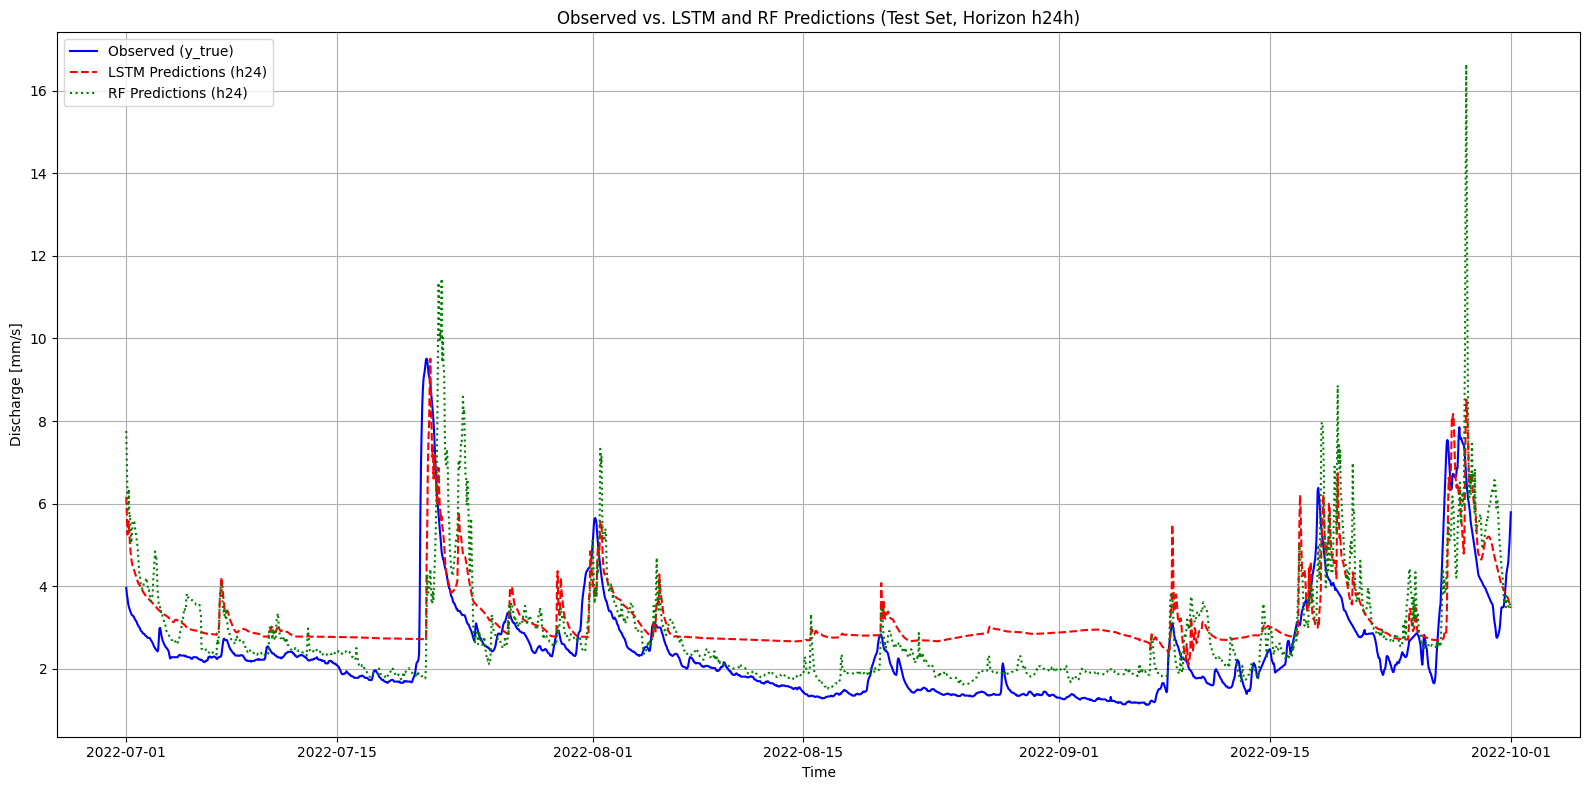

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Choose a horizon to plot (e.g., 'h3', 'h6', 'h12', 'h24', 'h72')
horizon_to_plot = 'h24'

# --- Adjust the plotted time length here ---
# Set start and end dates to filter the data. Use None for no filter on that side.
start_date = '2022-07-01' # Example: '2023-01-01'
end_date = '2022-10-01'  # Example: '2024-03-31'
# -----------------------------------------

# --- Get LSTM Test Data ---
lstm_df = loaded_predictions.get(horizon_to_plot)
if lstm_df is None:
    print(f"Error: LSTM predictions for horizon {horizon_to_plot} not found in loaded_predictions.")
    print("Available LSTM horizons:", loaded_predictions.keys())
else:
    print(f"Found LSTM data for {horizon_to_plot}.")
    # Ensure MESS_DATUM is datetime for plotting
    lstm_df['MESS_DATUM'] = pd.to_datetime(lstm_df['MESS_DATUM'])
    # Rename y_pred for clarity
    lstm_df = lstm_df.rename(columns={'y_pred': 'y_pred_lstm'})

# --- Get RF Test Data ---
rf_df = loaded_rf_predictions.get(f'{horizon_to_plot}_test')
if rf_df is None:
    print(f"Error: RF predictions for horizon {horizon_to_plot} (test set) not found in loaded_rf_predictions.")
    print("Available RF test horizons:", [k for k in loaded_rf_predictions.keys() if '_test' in k])
else:
    print(f"Found RF test data for {horizon_to_plot}.")
    # Ensure MESS_DATUM is datetime for plotting
    rf_df['MESS_DATUM'] = pd.to_datetime(rf_df['MESS_DATUM'])
    # Rename y_pred for clarity
    rf_df = rf_df.rename(columns={'y_pred': 'y_pred_rf'})

# --- Merge and Plot if both dataframes are available ---
if lstm_df is not None and rf_df is not None:
    # Merge the dataframes on MESS_DATUM
    merged_df = pd.merge(
        lstm_df[['MESS_DATUM', 'y_true', 'y_pred_lstm']],
        rf_df[['MESS_DATUM', 'y_pred_rf']],
        on='MESS_DATUM',
        how='inner'
    )

    # Sort by time for proper plotting
    merged_df = merged_df.sort_values(by='MESS_DATUM')

    # Apply date filtering
    if start_date:
        merged_df = merged_df[merged_df['MESS_DATUM'] >= pd.to_datetime(start_date)]
    if end_date:
        merged_df = merged_df[merged_df['MESS_DATUM'] <= pd.to_datetime(end_date)]

    # Create the plot
    plt.figure(figsize=(16, 8))
    plt.plot(merged_df['MESS_DATUM'], merged_df['y_true'], label='Observed (y_true)', color='blue')
    plt.plot(merged_df['MESS_DATUM'], merged_df['y_pred_lstm'], label=f'LSTM Predictions ({horizon_to_plot})', color='red', linestyle='--')
    plt.plot(merged_df['MESS_DATUM'], merged_df['y_pred_rf'], label=f'RF Predictions ({horizon_to_plot})', color='green', linestyle=':')

    plt.title(f'Observed vs. LSTM and RF Predictions (Test Set, Horizon {horizon_to_plot}h)')
    plt.xlabel('Time')
    plt.ylabel('Discharge [mm/s]')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Could not generate plot because either LSTM or RF data was missing for the specified horizon.")

Generating combined multi-panel plot for Horizon h12h across selected periods...


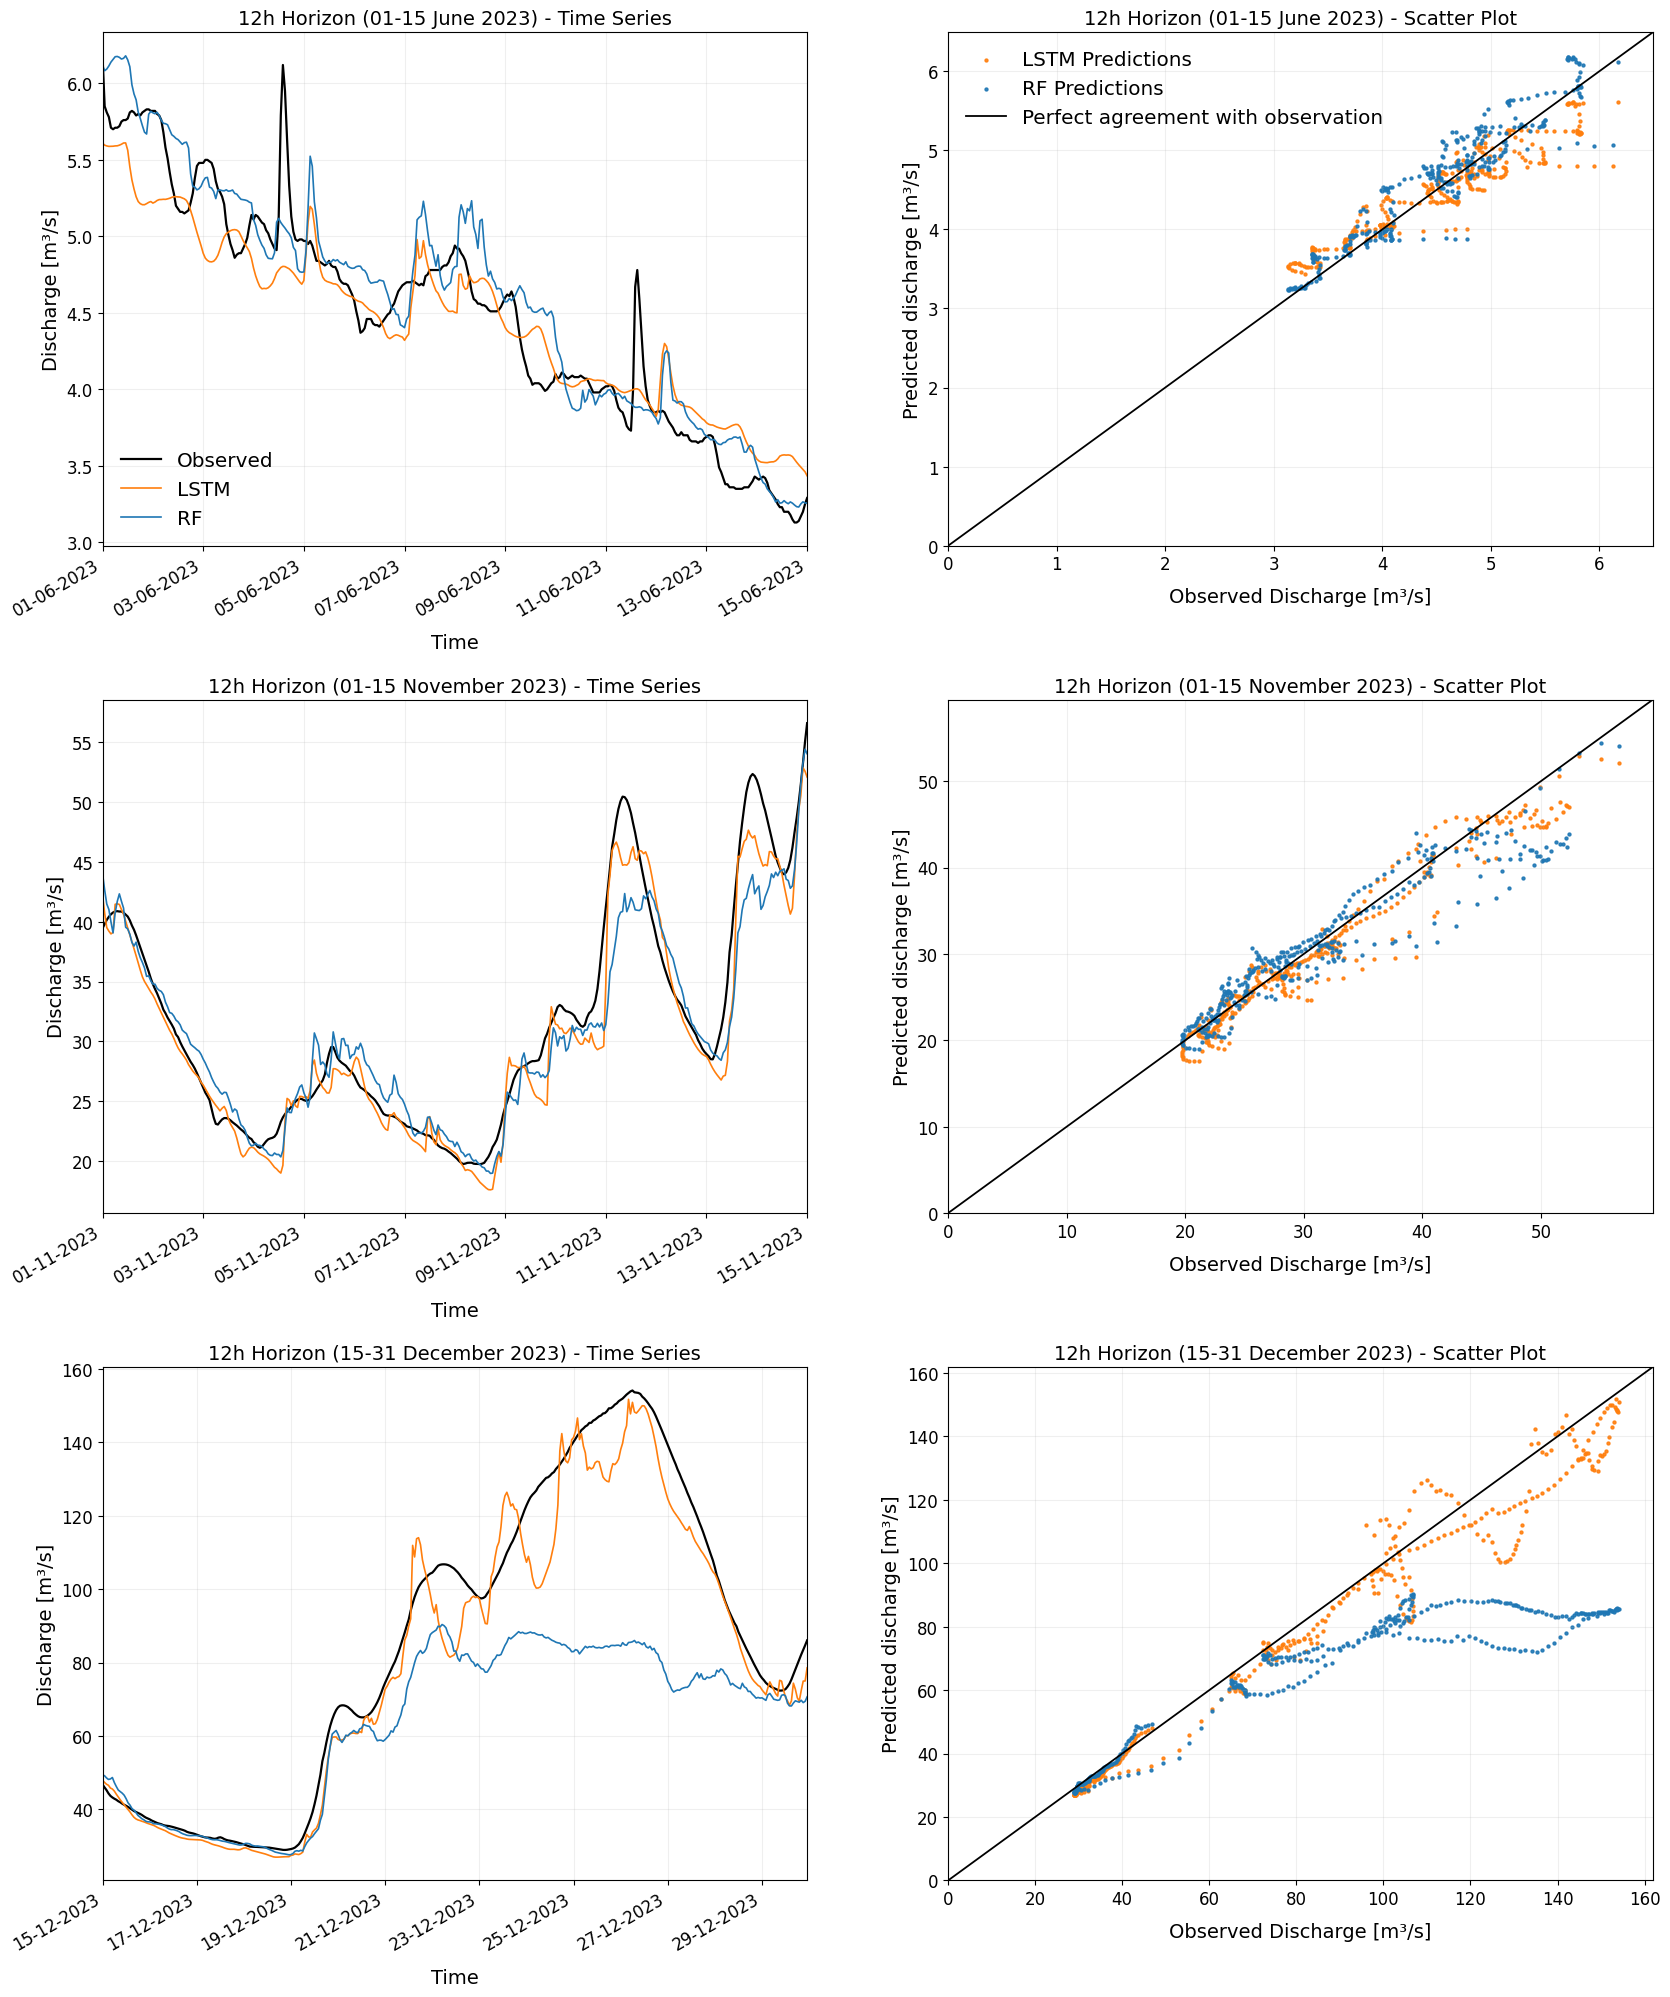

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # Import for date formatting

def plot_obs_lstm_rf(
    station_data,
    station_order=None,
    colors={"obs": "black", "lstm": "tab:orange", "rf": "tab:blue"},
    figsize=(20, 24), # Keeping a good height, but focusing on hspace
    s=18,
    alpha_scatter=0.9
):
    """
    Generates a combined plot with:
      - Left column: Time series (Observed, LSTM, RF) for each station/time range.
      - Right column: Scatter plots (Q_sim vs Q_observed + 1:1 line) for each station/time range.

    Parameters
    ----------
    station_data : dict
        dict with station_id -> DataFrame
        Each DataFrame must have columns: ["obs", "lstm", "rf"]
        and ideally a DatetimeIndex (or a "time" column).
        Example:
            station_data = {
                "US_0002272": df1,  # df1: index=datetime, cols=obs,lstm,rf
                "CA_0002429": df2,
                "US_0004590": df3
            }

    station_order : list[str] | None
        Order of stations/time ranges (Default: Keys-order)

    colors : dict
        Colors for obs/lstm/rf

    figsize : tuple
        Figure size

    s : int
        Marker size for scatter plots

    alpha_scatter : float
        Alpha for scatter points
    """

    if station_order is None:
        station_order = list(station_data.keys())

    # Ensure we only plot up to 3 stations as requested
    station_order = station_order[:3]
    num_rows = len(station_order) # Number of stations determines number of rows

    fig, axes = plt.subplots(
        nrows=num_rows, ncols=2, figsize=figsize,
        constrained_layout=False, # Disable constrained_layout to manually control spacing
        gridspec_kw={'hspace': 0.3, 'wspace': 0.2} # Manually set vertical and horizontal spacing, reduced hspace
    )

    # Make sure axes is always iterable and 2D for consistent indexing
    if num_rows == 1:
        axes = np.array([axes]) # Make it 2D if only one row

    for row, st in enumerate(station_order):
        df = station_data[st].copy()

        # If "time" column exists:
        if "time" in df.columns and not isinstance(df.index, pd.DatetimeIndex):
            df["time"] = pd.to_datetime(df["time"])
            df = df.set_index("time")

        # Cleanup: only needed columns, remove NaNs (for Scatter)
        needed = ["obs", "lstm", "rf"]
        missing = [c for c in needed if c not in df.columns]
        if missing:
            raise ValueError(f"Station {st}: Missing columns: {missing}. Expected: {needed}")

        # --- Left Column: Time Series Plot ----
        ax_ts = axes[row, 0]
        ax_ts.plot(df.index, df["obs"], color=colors["obs"], lw=1.6, label="Observed")
        ax_ts.plot(df.index, df["lstm"], color=colors["lstm"], lw=1.2, label="LSTM")
        ax_ts.plot(df.index, df["rf"], color=colors["rf"], lw=1.2, label="RF")

        ax_ts.set_title(f'{st} - Time Series', fontsize=14) # Increased title fontsize
        ax_ts.set_ylabel("Discharge [m³/s]", fontsize=14) # Increased ylabel fontsize
        ax_ts.grid(True, alpha=0.2)
        ax_ts.set_xlim(df.index.min(), df.index.max()) # Ensure full range
        ax_ts.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
        ax_ts.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax_ts.set_xlabel("Time", labelpad=10, fontsize=14) # Increased xlabel fontsize
        # Explicitly rotate and align tick labels for time series plots
        plt.setp(ax_ts.get_xticklabels(), rotation=30, ha='right', fontsize=12) # Increased tick label fontsize
        plt.setp(ax_ts.get_yticklabels(), fontsize=12) # Set y-tick label fontsize

        if row == 0: # Add legend only to the first time series plot
            ax_ts.legend(loc="lower left", frameon=False, fontsize='x-large') # Increased legend fontsize


        # --- Right Column: Scatter Plot (Q_sim vs Q_obs) ---
        ax_sc = axes[row, 1]
        dsc = df[needed].dropna()

        ax_sc.scatter(
            dsc["obs"], dsc["lstm"],
            s=s, marker=".", color=colors["lstm"], alpha=alpha_scatter, label="LSTM Predictions"
        )
        ax_sc.scatter(
            dsc["obs"], dsc["rf"],
            s=s, marker=".", color=colors["rf"], alpha=alpha_scatter, label="RF Predictions"
        )

        # 1:1 Linie
        maxv = np.nanmax([dsc["obs"].max(), dsc["lstm"].max(), dsc["rf"].max()])
        maxv *= 1.05 # Extend by 5%

        ax_sc.plot([0, maxv], [0, maxv], color="black", lw=1.3, label="Perfect agreement with observation") # Added label for 1:1 line

        ax_sc.set_xlim(0, maxv)
        ax_sc.set_ylim(0, maxv)
        ax_sc.set_title(f'{st} - Scatter Plot', fontsize=14) # Increased title fontsize
        ax_sc.set_ylabel("Predicted discharge [m³/s]", fontsize=14) # Increased ylabel fontsize
        ax_sc.grid(True, alpha=0.2)
        ax_sc.set_xlabel("Observed Discharge [m³/s]", labelpad=10, fontsize=14) # Increased xlabel fontsize
        # Explicitly rotate and align tick labels for scatter plots
        plt.setp(ax_sc.get_xticklabels(), rotation=0, ha='center', fontsize=12) # Increased tick label fontsize
        plt.setp(ax_sc.get_yticklabels(), fontsize=12) # Set y-tick label fontsize

        if row == 0: # Add legend only to the first scatter plot
            ax_sc.legend(loc="upper left", frameon=False, fontsize='x-large') # Increased legend fontsize

    # Removed fig.autofmt_xdate as we are manually setting rotations
    # plt.tight_layout() # This might interfere with manual spacing, keep it disabled for now if hspace is enough
    plt.show()


# --- Prepare data for the plot_obs_lstm_rf function ---

# Choose the horizon you want to plot
plot_horizon = 'h12' # User specified 'h12'

# Get LSTM data for the chosen horizon
lstm_data = loaded_predictions.get(plot_horizon)
# Rename columns for consistency and ensure datetime format
lstm_data_processed = lstm_data[['MESS_DATUM', 'y_true', 'y_pred']].copy()
lstm_data_processed.columns = ['MESS_DATUM', 'obs', 'lstm']
lstm_data_processed['MESS_DATUM'] = pd.to_datetime(lstm_data_processed['MESS_DATUM'])

# Get RF test data for the chosen horizon
rf_data = loaded_rf_predictions.get(f'{plot_horizon}_test')
# Rename columns for consistency and ensure datetime format
rf_data_processed = rf_data[['MESS_DATUM', 'y_pred']].copy() # Only need y_pred, y_true will come from LSTM
rf_data_processed.columns = ['MESS_DATUM', 'rf']
rf_data_processed['MESS_DATUM'] = pd.to_datetime(rf_data_processed['MESS_DATUM'])


# Merge on MESS_DATUM
merged_plot_df = pd.merge(lstm_data_processed, rf_data_processed, on='MESS_DATUM', how='inner')
merged_plot_df = merged_plot_df.set_index('MESS_DATUM').sort_index()

# Define the three time ranges with updated titles
time_ranges = [
    ("2023-06-01", "2023-06-15", "01-15 June 2023"),
    ("2023-11-01", "2023-11-15", "01-15 November 2023"),
    ("2023-12-15", "2023-12-31", "15-31 December 2023")
]

station_data_for_plot = {}
station_order_for_plot = []

for i, (start_date_str, end_date_str, plot_title) in enumerate(time_ranges):
    start_date = pd.to_datetime(start_date_str)
    end_date = pd.to_datetime(end_date_str)

    filtered_df = merged_plot_df[(merged_plot_df.index >= start_date) & (merged_plot_df.index <= end_date)].copy()

    # MODIFIED LINE: Changed how station_id is formatted for the plot title
    station_id = f'{plot_horizon[1:]}h Horizon ({plot_title})'
    station_data_for_plot[station_id] = filtered_df
    station_order_for_plot.append(station_id)

print(f"Generating combined multi-panel plot for Horizon {plot_horizon}h across selected periods...")
plot_obs_lstm_rf(
    station_data=station_data_for_plot,
    station_order=station_order_for_plot,
    # figsize is now managed within the function, but can be overridden if needed
)


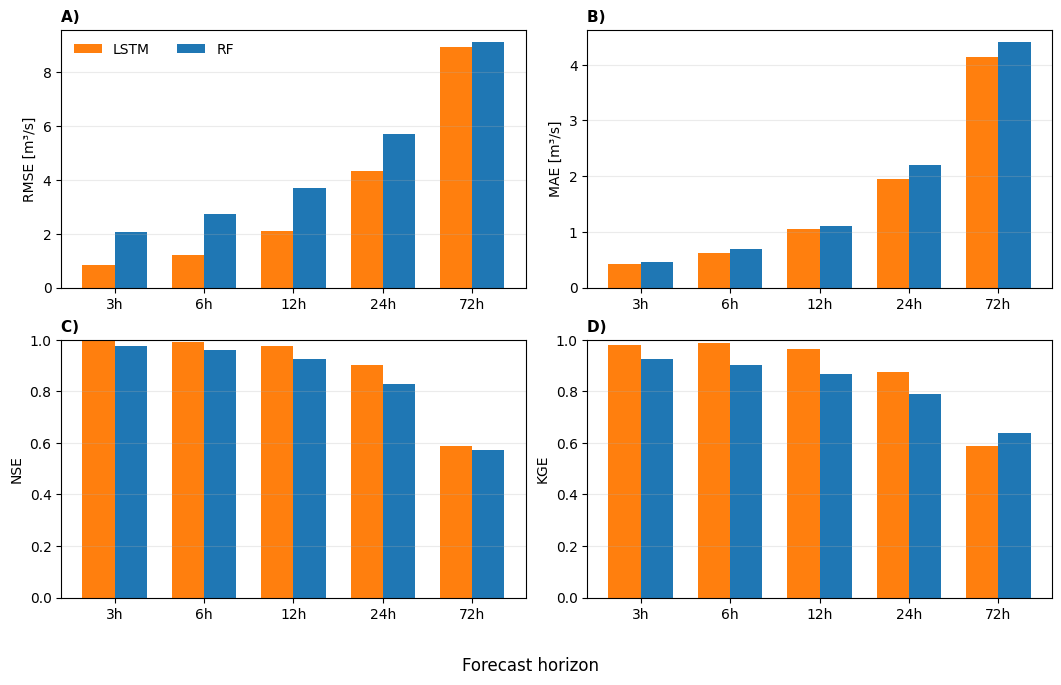

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

def plot_skill_bars(metrics_by_model, horizons, models=("LSTM", "RF")):


    metric_order = ["RMSE", "MAE", "NSE", "KGE"]  # Reordered as requested: RMSE A, MAE B, NSE C, KGE D
    # Updated titles: Removed metric names from MAE/RMSE titles as requested
    titles = {"NSE": "", "KGE": "", "MAE": "", "RMSE": ""}
    ylabels = {"NSE": "NSE", "KGE": "KGE", "MAE": "MAE [m³/s]", "RMSE": "RMSE [m³/s]"}

    # Figure
    fig, axes = plt.subplots(2, 2, figsize=(10.5, 6.2), constrained_layout=True)
    axes = axes.ravel()

    x = np.arange(len(horizons))
    width = 0.36  # Balkenbreite

    # Farbschema (du kannst das ändern)
    color_map = {"LSTM": "tab:orange", "RF": "tab:blue"} # Changed LSTM color to orange

    # Kleine helper-funktion für konsistente Horizon-Labels
    horizon_labels = [f"{h}h" for h in horizons]

    for i, metric in enumerate(metric_order):
        ax = axes[i]

        # Werte je Modell
        vals_0 = np.array(metrics_by_model[models[0]][metric], dtype=float)
        vals_1 = np.array(metrics_by_model[models[1]][metric], dtype=float)

        # Balken
        ax.bar(x - width/2, vals_0, width, label=models[0], color=color_map.get(models[0], None))
        ax.bar(x + width/2, vals_1, width, label=models[1], color=color_map.get(models[1], None))

        # Achsen/Style
        # The user requested to remove MAE, RMSE after A), B)... so the titles are empty string
        # The only remaining part is (A), (B), (C), (D).
        ax.set_title(f"{chr(65+i)}) {titles[metric]}", loc="left", fontsize=11, fontweight="bold")

        ax.set_xticks(x)
        ax.set_xticklabels(horizon_labels)
        ax.set_ylabel(ylabels[metric])
        ax.grid(True, axis="y", alpha=0.25)

        # Für NSE/KGE typische Grenzen optional (nur wenn sinnvoll)
        if metric in ["NSE", "KGE"]:
            ax.set_ylim(0.0, 1.0)

        # Add legend to the first plot only, as requested
        if i == 0:
            ax.legend(loc="upper left", ncol=2, frameon=False)

    # Custom placement for 'Forecast horizon' label
    # Removed fig.supxlabel as it was not giving desired control.
    # Manually place text using figure coordinates (0,0 is bottom-left, 1,1 is top-right)
    fig.text(0.5, -0.08, "Forecast horizon", ha='center', va='bottom', fontsize=12) # Adjusted y-coordinate

    # Removed global fig.legend() call as legend is now on the first ax

    plt.show()


# --- Metric calculation functions ---
def calculate_nse(y_true, y_pred):
    numerator = np.sum((y_true - y_pred) ** 2)
    denominator = np.sum((y_true - np.mean(y_true)) ** 2)
    # If denominator is zero, it means y_true are all the same value.
    # In this case, if y_pred is also constant and equal to y_true, NSE is 1.
    # If y_pred is not constant or not equal, NSE is undefined or negative infinity.
    # Returning NaN as a general indicator for problematic cases.
    if denominator == 0:
        return np.nan
    return 1 - (numerator / denominator)

def calculate_kge(y_true, y_pred):
    # KGE (Kling-Gupta Efficiency) 2012 version
    # Handle cases where std dev or mean might be zero or only one data point
    r = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 and np.std(y_true) > 0 and np.std(y_pred) > 0 else np.nan
    alpha = np.std(y_pred) / np.std(y_true) if np.std(y_true) > 0 else np.nan
    beta = np.mean(y_pred) / np.mean(y_true) if np.mean(y_true) != 0 else np.nan

    if np.isnan(r) or np.isnan(alpha) or np.isnan(beta):
        return np.nan

    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    return kge

def calculate_all_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    nse = calculate_nse(y_true, y_pred)
    kge = calculate_kge(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "NSE": nse, "KGE": kge}


# --- Prepare data and calculate metrics for plotting ---

# Extract horizons from loaded_predictions keys (e.g., 'h3' -> '3')
horizons = sorted([int(h[1:]) for h in loaded_predictions.keys()])

metrics_by_model = {
    "LSTM": {"NSE": [], "KGE": [], "MAE": [], "RMSE": []},
    "RF":   {"NSE": [], "KGE": [], "MAE": [], "RMSE": []},
}

for h in horizons:
    horizon_key = f'h{h}'

    # --- Get LSTM data ---
    lstm_df = loaded_predictions.get(horizon_key)

    # --- Get RF test data ---
    rf_df = loaded_rf_predictions.get(f'{horizon_key}_test')

    # Explicitly handle cases where data might be missing for a horizon
    if lstm_df is None or rf_df is None:
        print(f"Warning: Data for horizon {horizon_key} not found. Appending NaNs.")
        for metric_name in metrics_by_model["LSTM"].keys():
            metrics_by_model["LSTM"][metric_name].append(np.nan)
            metrics_by_model["RF"][metric_name].append(np.nan)
        continue # Skip to the next horizon

    # Ensure MESS_DATUM columns are datetime for merging
    lstm_df['MESS_DATUM'] = pd.to_datetime(lstm_df['MESS_DATUM'])
    rf_df['MESS_DATUM'] = pd.to_datetime(rf_df['MESS_DATUM'])

    # Merge dataframes on MESS_DATUM to ensure aligned y_true and y_pred
    # Using y_true from LSTM data as the reference true values
    merged_data = pd.merge(
        lstm_df[['MESS_DATUM', 'y_true', 'y_pred']],
        rf_df[['MESS_DATUM', 'y_pred']],
        on='MESS_DATUM',
        suffixes=('_lstm', '_rf'),
        how='inner'
    )

    # Drop rows with NaN values that might result from merge or original data
    merged_data.dropna(inplace=True)

    y_true = merged_data['y_true'].values
    y_pred_lstm = merged_data['y_pred_lstm'].values
    y_pred_rf = merged_data['y_pred_rf'].values

    # --- Calculate metrics for LSTM and RF using helper function ---
    lstm_calculated_metrics = calculate_all_metrics(y_true, y_pred_lstm)
    rf_calculated_metrics = calculate_all_metrics(y_true, y_pred_rf)

    for metric_name in metrics_by_model["LSTM"].keys(): # Assumes both models have same metric keys
        metrics_by_model["LSTM"][metric_name].append(lstm_calculated_metrics[metric_name])
        metrics_by_model["RF"][metric_name].append(rf_calculated_metrics[metric_name])

# --- Generate the plot ---
# Check if there is any valid data to plot before calling the function
plot_skill_bars(metrics_by_model, horizons)

